# Лабораторная работа №2
## «Обнаружение аномалий и выбросов в данных»

**Дисциплина:** Интеллектуальный анализ данных  
**Датасет:** `Housing.csv`  
**ФИО:** ______________________________  
**Группа:** ____________________________  
**Преподаватель:** _____________________

### Цель работы
1. Освоить методы обнаружения выбросов на основе статистических критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом предметной области.


## Задание 1. Загрузка и профилирование данных

Необходимо:
- загрузить датасет;
- выполнить `df.info()` и `df.describe()`;
- проверить пропуски;
- определить диапазоны значений;
- выявить подозрительные экстремальные значения;
- для двух числовых признаков построить гистограммы и boxplot;
- сделать вывод о возможных выбросах.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

df = pd.read_csv("Housing.csv")

print("Размер датасета:", df.shape)
display(df.head())


Размер датасета: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df.info()

print("\nОписательная статистика:")
display(df.describe(include="all").T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Описательная статистика:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.000,NaN,NaN,NaN,"4,766,729.248","1,870,439.616","1,750,000.000","3,430,000.000","4,340,000.000","5,740,000.000","13,300,000.000"
area,545.000,NaN,NaN,NaN,"5,150.541","2,170.141","1,650.000","3,600.000","4,600.000","6,360.000","16,200.000"
bedrooms,545.000,NaN,NaN,NaN,2.965,0.738,1.000,2.000,3.000,3.000,6.000
bathrooms,545.000,NaN,NaN,NaN,1.286,0.502,1.000,1.000,1.000,2.000,4.000
stories,545.000,NaN,NaN,NaN,1.806,0.867,1.000,1.000,2.000,2.000,4.000
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Пропуски:")
display(df.isna().sum().to_frame("missing"))

print("Количество дубликатов:", df.duplicated().sum())

nc = df.select_dtypes(include=np.number).columns.tolist()

print("\nЧисловые признаки:")
print(nc)

rg = pd.DataFrame({
    "min": df[nc].min(),
    "max": df[nc].max(),
    "range": df[nc].max() - df[nc].min()
})

print("\nДиапазоны:")
display(rg)


Пропуски:


,missing
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Количество дубликатов: 0

Числовые признаки:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Диапазоны:


,min,max,range
price,1750000,13300000,11550000
area,1650,16200,14550
bedrooms,1,6,5
bathrooms,1,4,3
stories,1,4,3
parking,0,3,3


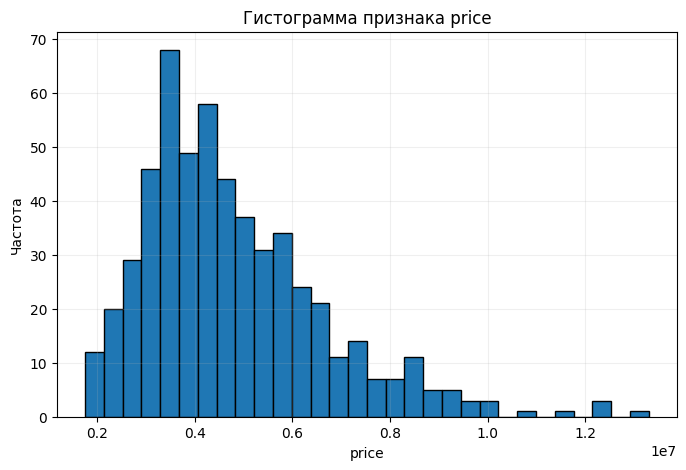

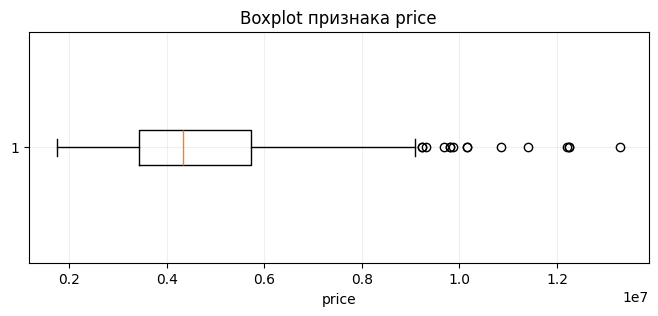

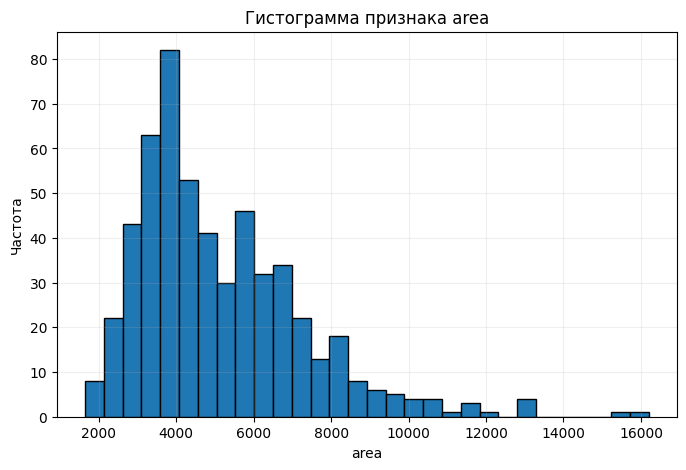

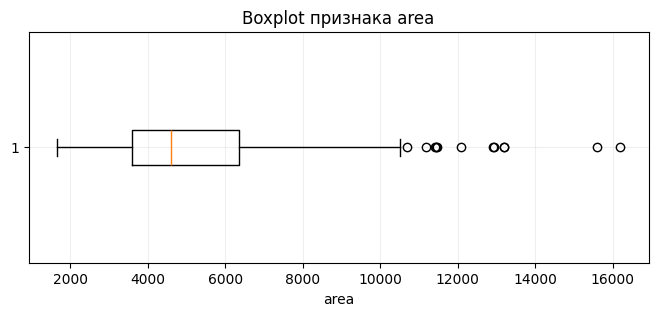

In [4]:
sf = ["price", "area"]

for c in sf:
    plt.figure(figsize=(8, 5))
    plt.hist(df[c].dropna(), bins=30, edgecolor="black")
    plt.title(f"Гистограмма признака {c}")
    plt.xlabel(c)
    plt.ylabel("Частота")
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot признака {c}")
    plt.xlabel(c)
    plt.grid(alpha=0.2)
    plt.show()


In [5]:
print(
    "Вывод по заданию 1:\n"
    f"Датасет содержит {df.shape[0]} наблюдений и {df.shape[1]} признаков.\n"
    f"Числовые признаки: {', '.join(nc)}.\n"
    f"Пропущенных значений: {int(df.isna().sum().sum())}.\n"
    f"Дубликатов: {int(df.duplicated().sum())}.\n\n"
    "Для price и area построены гистограммы и boxplot. "
    "По boxplot видны потенциально экстремальные наблюдения, "
    "поэтому далее они проверяются статистическими методами."
)


Вывод по заданию 1:
Датасет содержит 545 наблюдений и 13 признаков.
Числовые признаки: price, area, bedrooms, bathrooms, stories, parking.
Пропущенных значений: 0.
Дубликатов: 0.

Для price и area построены гистограммы и boxplot. По boxplot видны потенциально экстремальные наблюдения, поэтому далее они проверяются статистическими методами.


## Задание 2. Проверка нормальности распределения

Для `price` и `area` рассчитываются:
- среднее;
- медиана;
- стандартное отклонение;
- коэффициент асимметрии;
- коэффициент эксцесса.

Затем строятся QQ-графики и выполняется критерий Шапиро–Уилка.

**Гипотезы:**
- H0: выборка подчиняется нормальному распределению;
- H1: выборка не подчиняется нормальному распределению;
- α = 0.05.


In [6]:
nr = []

for c in sf:
    x = df[c].dropna()
    sh = stats.shapiro(x)
    nr.append({
        "feature": c,
        "mean": x.mean(),
        "median": x.median(),
        "std": x.std(),
        "skew": x.skew(),
        "kurt": x.kurtosis(),
        "shapiro_W": sh.statistic,
        "p_value": sh.pvalue
    })

nr = pd.DataFrame(nr)
display(nr)


,feature,mean,median,std,skew,kurt,shapiro_W,p_value
0,price,"4,766,729.248","4,340,000.000","1,870,439.616",1.212,1.960,0.922,0.000
1,area,"5,150.541","4,600.000","2,170.141",1.321,2.751,0.911,0.000


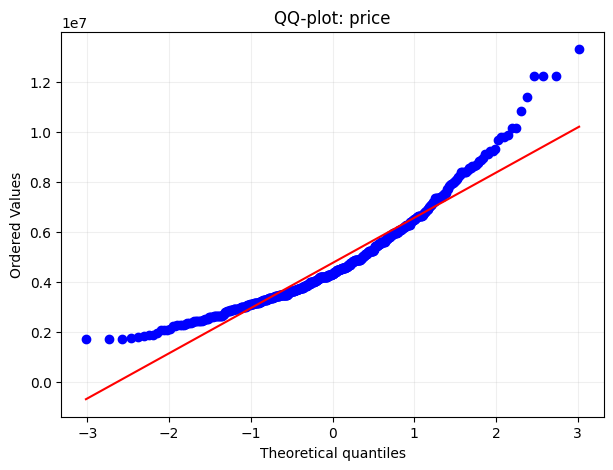

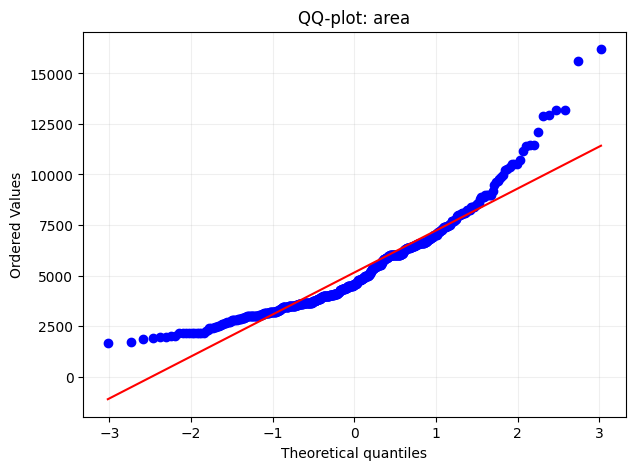

In [7]:
for c in sf:
    x = df[c].dropna()
    plt.figure(figsize=(7, 5))
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"QQ-plot: {c}")
    plt.grid(alpha=0.2)
    plt.show()


In [8]:
a = 0.05

nr["decision"] = np.where(
    nr["p_value"] < a,
    "Отклоняем H0",
    "Нет оснований отвергать H0"
)

display(nr[["feature", "shapiro_W", "p_value", "decision"]])

nr["dev_score"] = nr["skew"].abs() + nr["kurt"].abs()
cf = nr.loc[nr["dev_score"].idxmin(), "feature"]

print("Признак для задания 3:", cf)


,feature,shapiro_W,p_value,decision
0,price,0.922,0.000,Отклоняем H0
1,area,0.911,0.000,Отклоняем H0


Признак для задания 3: price


In [9]:
print(
    "Вывод по заданию 2:\n"
    "Для price и area выполнены описательные расчёты, QQ-анализ "
    "и критерий Шапиро–Уилка при α = 0.05.\n"
    "Если p-value < 0.05, H0 о нормальности отвергается.\n"
    f"По показателю |асимметрия| + |эксцесс| для задания 3 выбран признак {cf}."
)


Вывод по заданию 2:
Для price и area выполнены описательные расчёты, QQ-анализ и критерий Шапиро–Уилка при α = 0.05.
Если p-value < 0.05, H0 о нормальности отвергается.
По показателю |асимметрия| + |эксцесс| для задания 3 выбран признак price.


## Задание 3. Обнаружение выбросов статистическими методами

Для признака, выбранного по результатам задания 2:

### Метод Z-score
Выбросом считается наблюдение, для которого **|Z| > 3**.

### Метод IQR
Рассчитываются:
- Q1;
- Q3;
- IQR = Q3 − Q1;
- нижняя граница Q1 − 1.5 × IQR;
- верхняя граница Q3 + 1.5 × IQR.

После этого результаты двух методов сравниваются.


Признак: price
Количество выбросов Z-score: 6


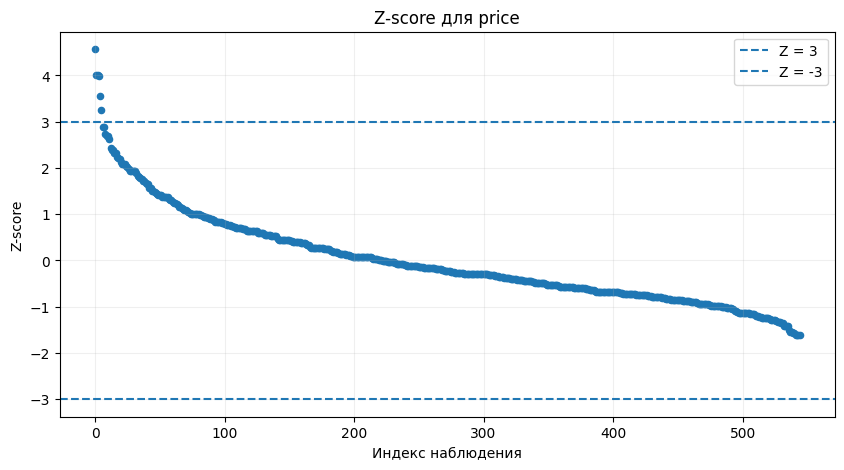

In [10]:
x = df[cf].dropna()

zs = pd.Series(stats.zscore(x), index=x.index)
zm = zs.abs() > 3
zo = df.loc[zm].copy()

print("Признак:", cf)
print("Количество выбросов Z-score:", int(zm.sum()))

plt.figure(figsize=(10, 5))
plt.scatter(zs.index, zs.values, s=20)
plt.axhline(3, linestyle="--", label="Z = 3")
plt.axhline(-3, linestyle="--", label="Z = -3")
plt.title(f"Z-score для {cf}")
plt.xlabel("Индекс наблюдения")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Q1 = 3430000.0
Q3 = 5740000.0
IQR = 2310000.0
Нижняя граница = -35000.0
Верхняя граница = 9205000.0
Количество выбросов IQR = 15


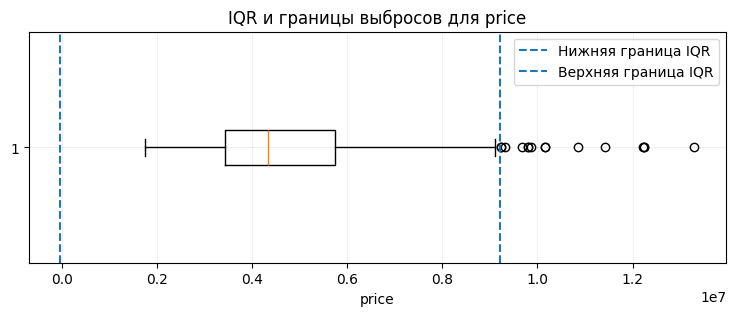

In [11]:
q1 = df[cf].quantile(0.25)
q3 = df[cf].quantile(0.75)
iq = q3 - q1

lo = q1 - 1.5 * iq
up = q3 + 1.5 * iq

im = (df[cf] < lo) | (df[cf] > up)
io = df.loc[im].copy()

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iq)
print("Нижняя граница =", lo)
print("Верхняя граница =", up)
print("Количество выбросов IQR =", int(im.sum()))

plt.figure(figsize=(9, 3))
plt.boxplot(df[cf].dropna(), vert=False)
plt.axvline(lo, linestyle="--", label="Нижняя граница IQR")
plt.axvline(up, linestyle="--", label="Верхняя граница IQR")
plt.title(f"IQR и границы выбросов для {cf}")
plt.xlabel(cf)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [12]:
cmp = pd.DataFrame({
    "method": ["Z-score", "IQR"],
    "outliers": [int(zm.sum()), int(im.sum())]
})

display(cmp)

print(
    f"Вывод по заданию 3: Z-score выявил {int(zm.sum())} выбросов, "
    f"IQR — {int(im.sum())}. Методы используют разные критерии, "
    "поэтому количество выбросов может отличаться. "
    "Выделенные объекты являются потенциальными выбросами и "
    "не должны автоматически удаляться без предметного анализа."
)


,method,outliers
0,Z-score,6
1,IQR,15


Вывод по заданию 3: Z-score выявил 6 выбросов, IQR — 15. Методы используют разные критерии, поэтому количество выбросов может отличаться. Выделенные объекты являются потенциальными выбросами и не должны автоматически удаляться без предметного анализа.


## Задание 4. Метод локальной плотности

Аномалия находится в области низкой плотности по сравнению с окружающими объектами.

Сначала числовые признаки стандартизируются через `StandardScaler`.

Используются Евклидово и Манхэттенское расстояния. Для `k = 5, 7, 9, 10` вычисляется **среднее расстояние до k ближайших соседей**.

Верхние **5%** значений среднего расстояния принимаются за потенциальные аномалии.

Дополнительно рассматривается локальная плотность:
**ρ(x) = 1 / Dk(x)**.


In [13]:
nf = df.select_dtypes(include=np.number).columns.tolist()

sc = StandardScaler()
xs = sc.fit_transform(df[nf])

print("Признаки:")
print(nf)
print("Размер стандартизированной матрицы:", xs.shape)


Признаки:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Размер стандартизированной матрицы: (545, 6)


In [14]:
ks = [5, 7, 9, 10]

er = []
em = {}
ek = {}

for k in ks:
    kn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean").fit(xs)
    ds, ind = kn.kneighbors(xs)

    kd = ds[:, k]
    md = ds[:, 1:k + 1].mean(axis=1)
    th = np.quantile(md, 0.95)
    an = md >= th
    rho = 1 / np.where(md == 0, np.finfo(float).eps, md)

    ek[k] = kd
    em[k] = md

    er.append({
        "k": k,
        "threshold_95": th,
        "anomalies": int(an.sum()),
        "share_%": an.mean() * 100,
        "mean_density": rho.mean()
    })

er = pd.DataFrame(er)
display(er)


,k,threshold_95,anomalies,share_%,mean_density
0,5,1.847,28,5.138,2.872
1,7,1.951,28,5.138,2.359
2,9,2.018,28,5.138,2.047
3,10,2.047,28,5.138,1.938


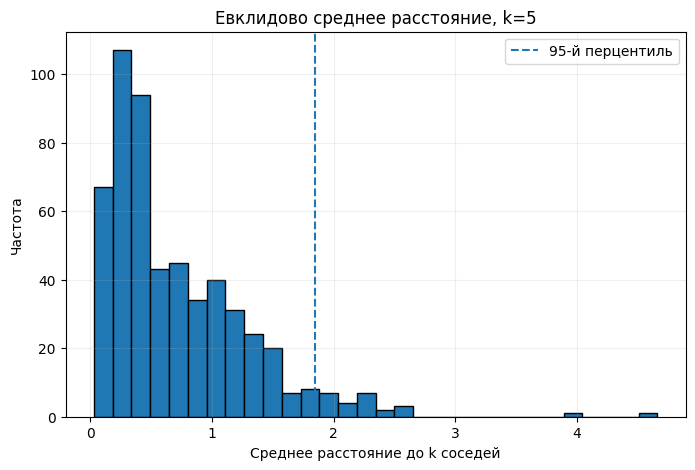

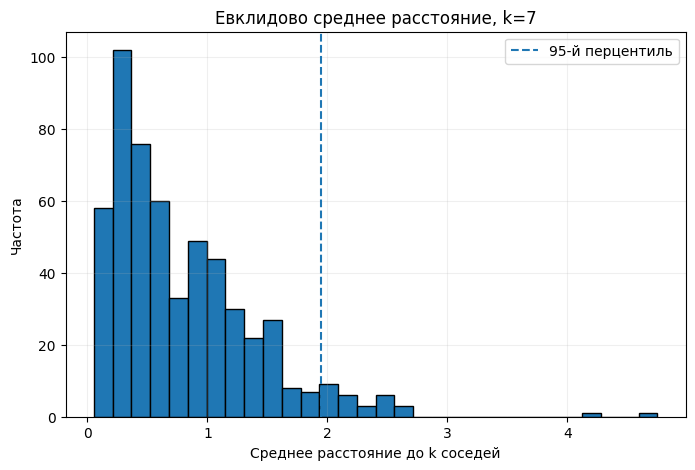

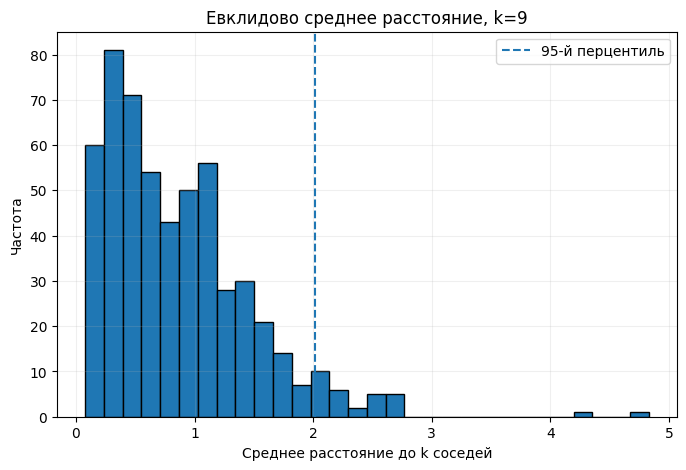

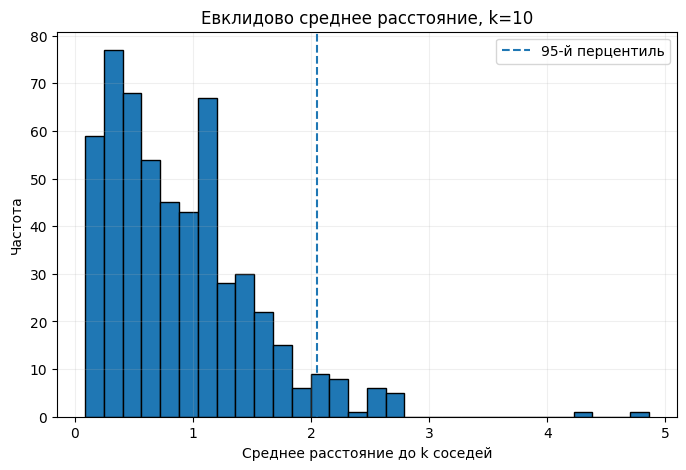

In [15]:
for k in ks:
    md = em[k]
    th = np.quantile(md, 0.95)

    plt.figure(figsize=(8, 5))
    plt.hist(md, bins=30, edgecolor="black")
    plt.axvline(th, linestyle="--", label="95-й перцентиль")
    plt.title(f"Евклидово среднее расстояние, k={k}")
    plt.xlabel("Среднее расстояние до k соседей")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


In [16]:
mr = []
mm = {}
mk = {}

for k in ks:
    kn = NearestNeighbors(n_neighbors=k + 1, metric="manhattan").fit(xs)
    ds, ind = kn.kneighbors(xs)

    kd = ds[:, k]
    md = ds[:, 1:k + 1].mean(axis=1)
    th = np.quantile(md, 0.95)
    an = md >= th
    rho = 1 / np.where(md == 0, np.finfo(float).eps, md)

    mk[k] = kd
    mm[k] = md

    mr.append({
        "k": k,
        "threshold_95": th,
        "anomalies": int(an.sum()),
        "share_%": an.mean() * 100,
        "mean_density": rho.mean()
    })

mr = pd.DataFrame(mr)
display(mr)


,k,threshold_95,anomalies,share_%,mean_density
0,5,2.594,28,5.138,2.315
1,7,2.851,28,5.138,1.891
2,9,3.053,28,5.138,1.636
3,10,3.137,28,5.138,1.545


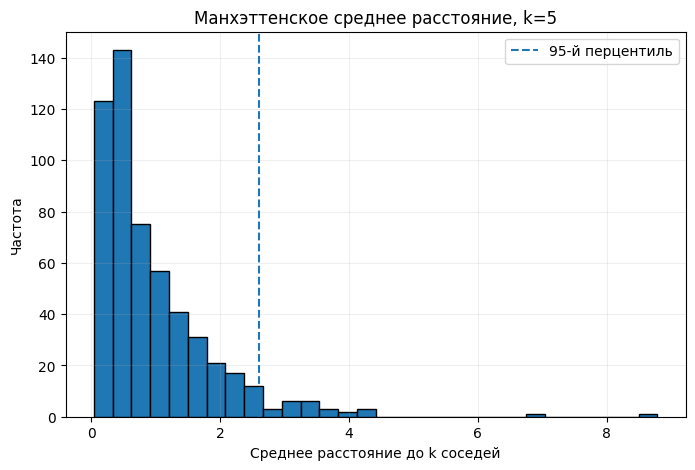

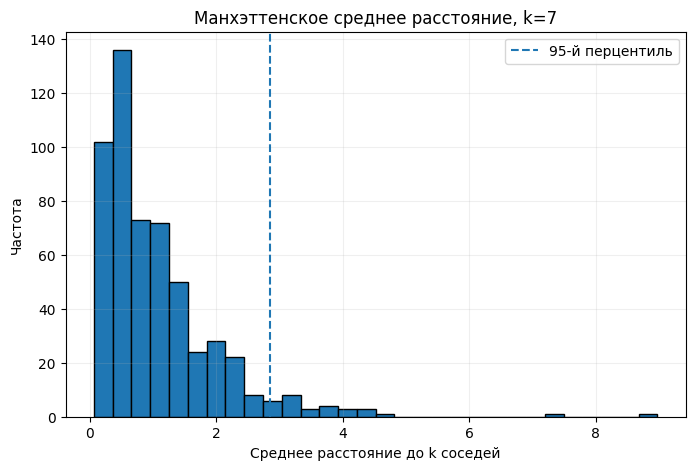

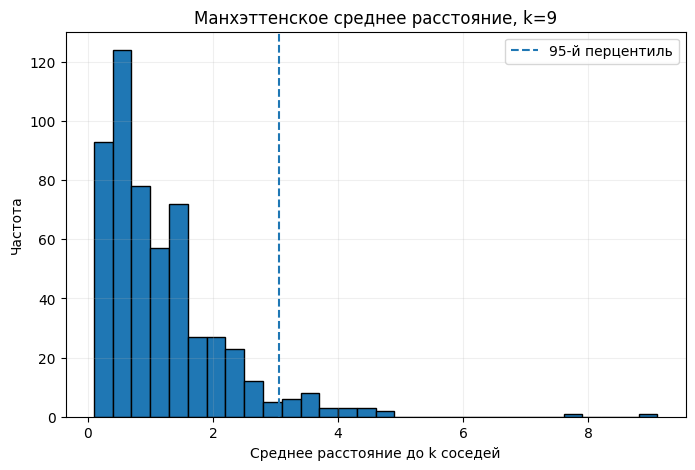

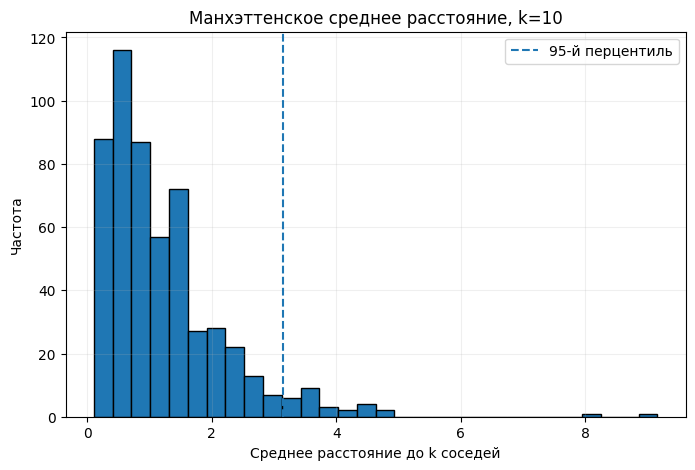

In [17]:
for k in ks:
    md = mm[k]
    th = np.quantile(md, 0.95)

    plt.figure(figsize=(8, 5))
    plt.hist(md, bins=30, edgecolor="black")
    plt.axvline(th, linestyle="--", label="95-й перцентиль")
    plt.title(f"Манхэттенское среднее расстояние, k={k}")
    plt.xlabel("Среднее расстояние до k соседей")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


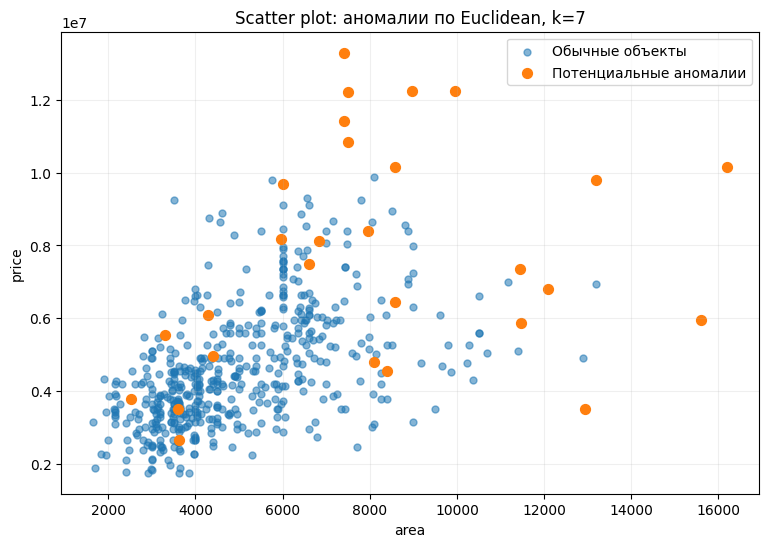

Количество потенциальных аномалий: 28


In [18]:
vk = 7
md = em[vk]
th = np.quantile(md, 0.95)
an = md >= th

plt.figure(figsize=(9, 6))
plt.scatter(
    df["area"], df["price"],
    s=25, alpha=0.55,
    label="Обычные объекты"
)
plt.scatter(
    df.loc[an, "area"], df.loc[an, "price"],
    s=50,
    label="Потенциальные аномалии"
)
plt.xlabel("area")
plt.ylabel("price")
plt.title(f"Scatter plot: аномалии по Euclidean, k={vk}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Количество потенциальных аномалий:", int(an.sum()))


In [19]:
st = er.merge(
    mr,
    on="k",
    suffixes=("_euclidean", "_manhattan")
)

display(st)

print(
    "Вывод по заданию 4: для каждого k верхние 5% значений "
    "среднего расстояния выделены как потенциальные аномалии. "
    "Изменение k меняет порог расстояния, поэтому сравнение результатов "
    "при k=5, 7, 9, 10 позволяет оценить устойчивость метода."
)


,k,threshold_95_euclidean,anomalies_euclidean,share_%_euclidean,mean_density_euclidean,threshold_95_manhattan,anomalies_manhattan,share_%_manhattan,mean_density_manhattan
0,5,1.847,28,5.138,2.872,2.594,28,5.138,2.315
1,7,1.951,28,5.138,2.359,2.851,28,5.138,1.891
2,9,2.018,28,5.138,2.047,3.053,28,5.138,1.636
3,10,2.047,28,5.138,1.938,3.137,28,5.138,1.545


Вывод по заданию 4: для каждого k верхние 5% значений среднего расстояния выделены как потенциальные аномалии. Изменение k меняет порог расстояния, поэтому сравнение результатов при k=5, 7, 9, 10 позволяет оценить устойчивость метода.


## Итоговый вывод

В работе выполнены все этапы, предусмотренные методичкой:

1. загрузка и профилирование `Housing.csv`;
2. анализ пропусков, диапазонов и экстремальных значений;
3. гистограммы и boxplot для двух числовых признаков;
4. описательные характеристики и QQ-графики;
5. критерий Шапиро–Уилка при α = 0.05;
6. Z-score с порогом |Z| > 3;
7. IQR и сравнение с Z-score;
8. масштабирование числовых признаков;
9. Евклидово и Манхэттенское расстояния;
10. анализ для k = 5, 7, 9, 10;
11. верхние 5% как потенциальные аномалии;
12. scatter plot и анализ устойчивости.

**Заключение:** статистически необычное наблюдение не обязательно является ошибкой. Решение об удалении или изменении аномальных объектов должно приниматься с учетом предметной области.
